In [120]:
import pandas as pd

import kagglehub

# Download latest version
path = kagglehub.dataset_download("yogeshm01/fifa-world-cup-2026-players-matches-dataset")

In [121]:
external_factors = pd.read_csv('external_factors.csv')
matches = pd.read_csv('matchesk.csv')
player = pd.read_csv('playersk.csv')
team = pd.read_csv('teamsk.csv')
venue = pd.read_csv('venuesk.csv')

In [122]:
external_factors.head()

,match_id,weather_condition,temperature,travel_distance_km,social_sentiment_home,social_sentiment_away,betting_odds_home,referee_strictness,fatigue_diff
0,M0001,Rain,20.6,6290,0.83,-0.14,2.79,8.0,1.2
1,M0002,Sunny,21.0,1356,0.75,-0.28,1.76,7.1,-1.5
2,M0003,Hot,29.7,3476,-0.15,0.10,3.26,6.8,-4.3
3,M0004,Hot,27.7,5745,-0.17,0.38,3.35,6.9,21.8
4,M0005,Sunny,20.4,5362,0.21,0.15,1.72,7.1,17.4


In [123]:
matches.head()

,match_id,date,team_home,team_away,venue_id,group_stage,predicted_win_prob_home,goals_home,goals_away,xG_home,xG_away,attendance
0,M0001,2026-06-11,T039,T028,V08,Knockout,0.531,0,4,1.28,1.07,66996
1,M0002,2026-06-12,T029,T047,V08,Group B,0.489,3,0,1.82,2.20,62122
2,M0003,2026-06-13,T015,T007,V03,Group B,0.398,3,3,1.02,1.76,69850
3,M0004,2026-06-14,T043,T044,V01,Group A,0.449,0,0,0.91,1.58,62350
4,M0005,2026-06-15,T008,T008,V08,Group B,0.447,1,4,1.84,1.79,62472


In [124]:
player.head()

,player_id,player_name,team_id,position,age,matches_played_2025_26,goals_2025_26,assists_2025_26,xG,xA,minutes_played,injury_risk,market_value_million,nationality,club,fatigue_score,social_mention_count
0,P0001,Lionel Messi,T017,DF,36,16,18,3,0.65,0.33,459,Low,100,France,Bayern Munich,79.4,174823
1,P0002,Erling Haaland,T009,DF,25,12,14,12,0.58,0.46,3385,Low,52,Argentina,Real Madrid,87.1,218135
2,P0003,Neymar Jr,T033,GK,34,38,3,11,0.90,0.22,3549,Medium,74,Brazil,Manchester City,59.6,111511
3,P0004,Erling Haaland,T020,FW,22,33,20,12,0.94,0.57,2759,Low,104,Germany,Bayern Munich,81.7,225461
4,P0005,Thomas Muller,T013,DF,33,12,12,13,0.27,0.29,1311,Low,63,France,Manchester City,56.2,150830


In [125]:
team.head()

,team_id,team_name,fifa_rank,elo_rating,confederation,squad_size,avg_age,market_value_million,recent_form,goals_scored_last_12m,goals_conceded_last_12m,head_coach
0,T001,Brazil,52,1566,UEFA,24,25.4,246,WDWLW,68,38,Scaloni
1,T002,Argentina,93,1673,CONMEBOL,24,27.2,963,LWDWW,65,27,Scaloni
2,T003,France,15,1787,AFC,25,24.0,588,LWDWW,72,21,Flick
3,T004,England,72,2000,AFC,24,25.8,1028,WWDLW,50,50,Scaloni
4,T005,Germany,61,1715,AFC,22,25.5,650,LWDWW,54,59,Flick


In [126]:
venue.head()

,venue_id,venue_name,city,country,capacity,avg_temperature,humidity,pitch_quality_score
0,V01,MetLife,New York,USA,82500,24.5,55,9.2
1,V02,SoFi,LA,USA,70000,26.0,48,9.5
2,V03,AT&T,Dallas,USA,80000,28.5,62,8.8
3,V04,Azteca,Mexico City,Mexico,87000,27.0,58,9.0
4,V05,BC Place,Vancouver,Canada,54000,19.0,65,8.5


In [127]:
# merge csv's to create to dataframes: 1=matchmerge(matches, external_factors, venue) 2=teamplay(team, player)
# to be used for a simple linear regression model

# venue - venue id, venue_name,city, country, avg_temp, humidity, pitch_quality
# external_factors - travel_distance_km, match_id
# matches - match_id, date, team_home, team_away, venue_id
# player - team_id, matches_played_2025_26,	goals_2025_26
# team - team_id, team_name, goals_scored_last_12m,	goals_conceded_last_12m


In [128]:
# view dataFrame keys for use in merge
print('venue keys: ', venue.keys())
print('external keys: ', external_factors.keys())
print('match keys: ', matches.keys())
print('player keys: ', player.keys())
print('team keys: ', team.keys())

venue keys:  Index(['venue_id', 'venue_name', 'city', 'country', 'capacity',
       'avg_temperature', 'humidity', 'pitch_quality_score'],
      dtype='str')
external keys:  Index(['match_id', 'weather_condition', 'temperature', 'travel_distance_km',
       'social_sentiment_home', 'social_sentiment_away', 'betting_odds_home',
       'referee_strictness', 'fatigue_diff'],
      dtype='str')
match keys:  Index(['match_id', 'date', 'team_home', 'team_away', 'venue_id', 'group_stage',
       'predicted_win_prob_home', 'goals_home', 'goals_away', 'xG_home',
       'xG_away', 'attendance'],
      dtype='str')
player keys:  Index(['player_id', 'player_name', 'team_id', 'position', 'age',
       'matches_played_2025_26', 'goals_2025_26', 'assists_2025_26', 'xG',
       'xA', 'minutes_played', 'injury_risk', 'market_value_million',
       'nationality', 'club', 'fatigue_score', 'social_mention_count'],
      dtype='str')
team keys:  Index(['team_id', 'team_name', 'fifa_rank', 'elo_rating', 'co

In [129]:
# create datafram with only the useful infomation
venue2 = venue[['venue_id', 'venue_name', 'city', 'country', 'avg_temperature', 'humidity', 'pitch_quality_score']]
ext_fact = external_factors[['match_id', 'travel_distance_km', 'weather_condition', 'temperature']]
matches2 = matches[['match_id', 'date', 'team_home', 'team_away', 'venue_id', 'group_stage', 'predicted_win_prob_home', 'goals_home', 'goals_away']]
players = player[['player_id', 'player_name', 'team_id', 'position', 'age', 'matches_played_2025_26', 'goals_2025_26', 'assists_2025_26', 'minutes_played', 'injury_risk', 'fatigue_score']]
teams = team[['team_id', 'team_name', 'recent_form', 'goals_scored_last_12m', 'goals_conceded_last_12m']]


In [130]:
# create merge 1
matchmerg = pd.merge(matches2, venue2, on=['venue_id'])

In [131]:
# create merge 2
matchmerge = pd.merge(matchmerg, ext_fact, on=['match_id'])

In [132]:
# create merge 3
teamplay = pd.merge(teams, players, on=['team_id'])

In [133]:
# review merged dataframe
teamplay.head()

,team_id,team_name,recent_form,goals_scored_last_12m,goals_conceded_last_12m,player_id,player_name,position,age,matches_played_2025_26,goals_2025_26,assists_2025_26,minutes_played,injury_risk,fatigue_score
0,T001,Brazil,WDWLW,68,38,P0023,Harry Kane,MF,36,30,16,15,1398,Low,61.5
1,T001,Brazil,WDWLW,68,38,P0038,Thomas Muller,DF,30,41,23,2,1117,Low,82.9
2,T001,Brazil,WDWLW,68,38,P0060,Jude Bellingham,DF,30,43,9,16,1406,Low,53.2
3,T001,Brazil,WDWLW,68,38,P0064,Lionel Messi,MF,24,18,7,15,2295,Low,68.8
4,T001,Brazil,WDWLW,68,38,P0076,Thomas Muller,MF,18,29,24,8,2522,Low,42.8


In [134]:
# review merged dataframe
matchmerge.head()

,match_id,date,team_home,team_away,venue_id,group_stage,predicted_win_prob_home,goals_home,goals_away,venue_name,city,country,avg_temperature,humidity,pitch_quality_score,travel_distance_km,weather_condition,temperature
0,M0001,2026-06-11,T039,T028,V08,Knockout,0.531,0,4,NRG,Houston,USA,29.0,70,8.7,6290,Rain,20.6
1,M0002,2026-06-12,T029,T047,V08,Group B,0.489,3,0,NRG,Houston,USA,29.0,70,8.7,1356,Sunny,21.0
2,M0003,2026-06-13,T015,T007,V03,Group B,0.398,3,3,AT&T,Dallas,USA,28.5,62,8.8,3476,Hot,29.7
3,M0004,2026-06-14,T043,T044,V01,Group A,0.449,0,0,MetLife,New York,USA,24.5,55,9.2,5745,Hot,27.7
4,M0005,2026-06-15,T008,T008,V08,Group B,0.447,1,4,NRG,Houston,USA,29.0,70,8.7,5362,Sunny,20.4


In [135]:
# from week 8 Explore the relationship between variables:
# Linear regression, as the name suggests, works best if a linear relationship exists between each explanatory variable and 
# the response variable. 
# first we will explore if there is a linear relationship between two variables.


In [136]:
import matplotlib.pyplot as plt
import numpy as np

In [137]:
teamplay.info()

<class 'pandas.DataFrame'>
RangeIndex: 19200 entries, 0 to 19199
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   team_id                  19200 non-null  str    
 1   team_name                19200 non-null  str    
 2   recent_form              19200 non-null  str    
 3   goals_scored_last_12m    19200 non-null  int64  
 4   goals_conceded_last_12m  19200 non-null  int64  
 5   player_id                19200 non-null  str    
 6   player_name              19200 non-null  str    
 7   position                 19200 non-null  str    
 8   age                      19200 non-null  int64  
 9   matches_played_2025_26   19200 non-null  int64  
 10  goals_2025_26            19200 non-null  int64  
 11  assists_2025_26          19200 non-null  int64  
 12  minutes_played           19200 non-null  int64  
 13  injury_risk              19200 non-null  str    
 14  fatigue_score            19200 no

In [138]:
teamplay['goals_scored_last_12m'] = teamplay['goals_scored_last_12m'].astype(float)
teamplay['goals_conceded_last_12m'] = teamplay['goals_conceded_last_12m'].astype(float)
teamplay['matches_played_2025_26'] = teamplay['matches_played_2025_26'].astype(float)
teamplay['goals_2025_26'] = teamplay['goals_2025_26'].astype(float)
teamplay['assists_2025_26'] = teamplay['assists_2025_26'].astype(float)
teamplay['minutes_played'] = teamplay['minutes_played'].astype(float)
teamplay['fatigue_score'] = teamplay['fatigue_score'].astype(float)

In [139]:
teamplay['team_id'] = pd.to_numeric(teamplay['team_id'], errors='coerce')

In [140]:
teamplay.info()

<class 'pandas.DataFrame'>
RangeIndex: 19200 entries, 0 to 19199
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   team_id                  0 non-null      float64
 1   team_name                19200 non-null  str    
 2   recent_form              19200 non-null  str    
 3   goals_scored_last_12m    19200 non-null  float64
 4   goals_conceded_last_12m  19200 non-null  float64
 5   player_id                19200 non-null  str    
 6   player_name              19200 non-null  str    
 7   position                 19200 non-null  str    
 8   age                      19200 non-null  int64  
 9   matches_played_2025_26   19200 non-null  float64
 10  goals_2025_26            19200 non-null  float64
 11  assists_2025_26          19200 non-null  float64
 12  minutes_played           19200 non-null  float64
 13  injury_risk              19200 non-null  str    
 14  fatigue_score            19200 no

In [141]:
teamplay.describe()

,team_id,goals_scored_last_12m,goals_conceded_last_12m,age,matches_played_2025_26,goals_2025_26,assists_2025_26,minutes_played,fatigue_score
count,0.0,19200.000000,19200.0000,19200.000000,19200.000000,19200.000000,19200.000000,19200.000000,19200.000000
mean,NaN,53.543333,39.1400,27.650000,26.603333,11.530000,8.683333,2096.513333,65.719000
std,NaN,15.213377,12.5667,5.602601,10.035831,7.416556,5.126834,974.593765,15.848731
min,NaN,21.000000,15.0000,18.000000,10.000000,0.000000,0.000000,322.000000,40.300000
25%,NaN,44.000000,29.0000,23.000000,18.000000,5.000000,4.000000,1309.750000,52.075000
50%,NaN,52.000000,37.0000,28.000000,26.000000,11.000000,9.000000,2103.500000,64.250000
75%,NaN,66.000000,49.2500,32.000000,35.000000,18.000000,13.000000,2911.250000,80.125000
max,NaN,79.000000,59.0000,37.000000,44.000000,24.000000,17.000000,3792.000000,94.900000


In [142]:
# Bivariate analysis: Continuous vs. continuous variables
# explore correlations among continuous variables in the teamplay dataset. 
# compute the Pearson's Correlation score between two variables = var 1 and var 2, 
# Then compute the correlation matrix when more than two variables are involved. 
# Create two visualisations: scatterplot and heatmap.
import numpy.random as rnd
import seaborn as sns

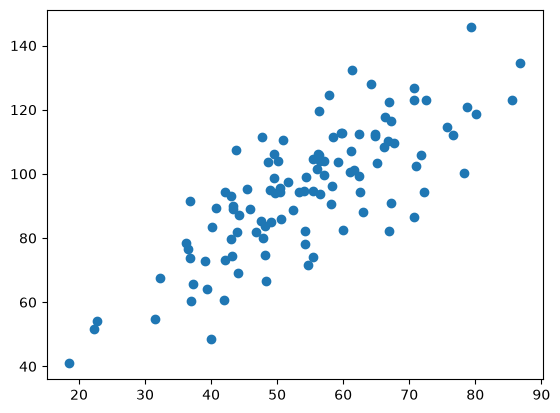

In [143]:
# var 1
rnd.seed(1)
var1 = rnd.normal(loc=53.543333, scale=15.213377, size=110) # goals_scored_last_12m - loc=mean, scale=std dev, size=number of scatter dots

# var 2
var2 = var1 + (rnd.normal(loc=39.1400, scale=12.5667, size=110)) # goals_conceded_last_12m

# scatterplot
plt.scatter(var1, var2)

In [144]:
# pearsons r
import scipy.stats as st

# calculation
corr, _ = st.pearsonr(var1, var2)
print("Pearson's r Correlation: ", corr)

Pearson's r Correlation:  0.7779038778807378


In [145]:
# pulls numeric valuse only from the teamplay dataFrame corr = correlation
corr = teamplay.corr(numeric_only=True)

In [146]:
# review corr dataframe
corr

,team_id,goals_scored_last_12m,goals_conceded_last_12m,age,matches_played_2025_26,goals_2025_26,assists_2025_26,minutes_played,fatigue_score
team_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
goals_scored_last_12m,NaN,1.000000,0.018067,-0.028314,-0.010466,-0.017886,0.100293,0.023269,-0.007907
goals_conceded_last_12m,NaN,0.018067,1.000000,-0.022125,0.030044,-0.037421,-0.013282,-0.049098,-0.013331
age,NaN,-0.028314,-0.022125,1.000000,0.057648,0.022515,-0.073259,-0.010018,0.008845
matches_played_2025_26,NaN,-0.010466,0.030044,0.057648,1.000000,0.001795,0.037598,-0.107051,0.059772
goals_2025_26,NaN,-0.017886,-0.037421,0.022515,0.001795,1.000000,0.029575,-0.074259,-0.101365
assists_2025_26,NaN,0.100293,-0.013282,-0.073259,0.037598,0.029575,1.000000,0.030794,-0.025272
minutes_played,NaN,0.023269,-0.049098,-0.010018,-0.107051,-0.074259,0.030794,1.000000,0.082937
fatigue_score,NaN,-0.007907,-0.013331,0.008845,0.059772,-0.101365,-0.025272,0.082937,1.000000


Plot the correlation matrix of 'teamplay' using heatmap seaborn package


<Axes: >

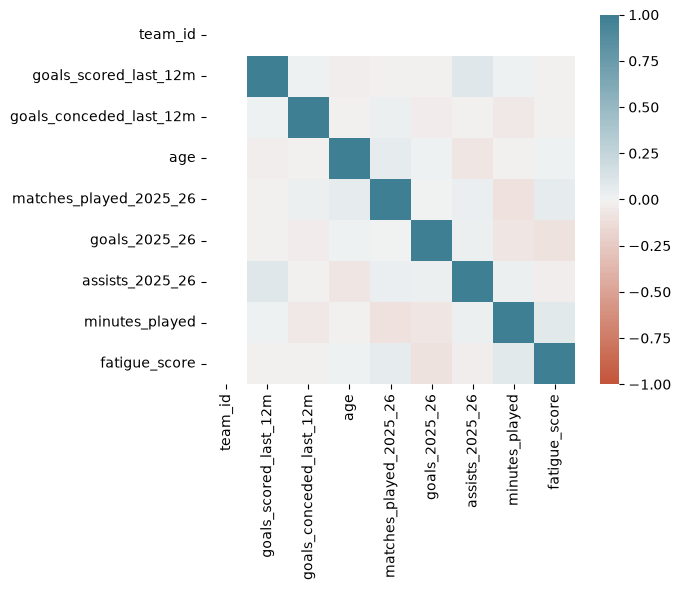

In [147]:
# review teamplay dataframe using heatmap visulisation
print("Plot the correlation matrix of 'teamplay' using heatmap seaborn package")
sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)

In [148]:
teamplay.info()

<class 'pandas.DataFrame'>
RangeIndex: 19200 entries, 0 to 19199
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   team_id                  0 non-null      float64
 1   team_name                19200 non-null  str    
 2   recent_form              19200 non-null  str    
 3   goals_scored_last_12m    19200 non-null  float64
 4   goals_conceded_last_12m  19200 non-null  float64
 5   player_id                19200 non-null  str    
 6   player_name              19200 non-null  str    
 7   position                 19200 non-null  str    
 8   age                      19200 non-null  int64  
 9   matches_played_2025_26   19200 non-null  float64
 10  goals_2025_26            19200 non-null  float64
 11  assists_2025_26          19200 non-null  float64
 12  minutes_played           19200 non-null  float64
 13  injury_risk              19200 non-null  str    
 14  fatigue_score            19200 no

In [149]:
# run the same coding on the matchmerge dataframe
# Bivariate analysis: Continuous vs. continuous variables
# explore correlations among continuous variables in the teamplay dataset. 
# compute the Pearson's Correlation score between two variables = var 1 and var 2, 
# Then compute the correlation matrix when more than two variables are involved. 
# Create two visualisations: scatterplot and heatmap.
matchmerge.describe()

,predicted_win_prob_home,goals_home,goals_away,avg_temperature,humidity,pitch_quality_score,travel_distance_km,temperature
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.516080,1.800000,1.920000,25.900000,60.200000,8.874000,3401.220000,25.926000
std,0.072468,1.371989,1.482007,3.499329,6.932537,0.246577,1764.884771,4.797572
min,0.389000,0.000000,0.000000,19.000000,48.000000,8.500000,109.000000,19.200000
25%,0.449000,0.000000,1.000000,24.500000,55.000000,8.700000,1938.000000,20.600000
50%,0.518500,2.000000,2.000000,27.500000,59.000000,8.850000,3453.000000,26.150000
75%,0.572000,3.000000,3.000000,28.500000,65.000000,9.000000,5064.000000,30.400000
max,0.649000,4.000000,4.000000,30.500000,75.000000,9.500000,6290.000000,32.900000


Text(0, 0.5, 'predicted win probability')

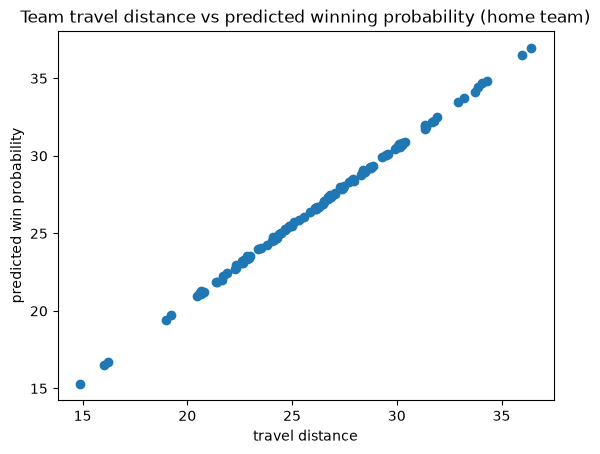

In [150]:
# var 1 - travel distance
rnd.seed(1)
var3 = rnd.normal(loc=25.926000, scale=4.797572, size=110) # loc=mean, scale=std dev, size=number of scatter dots

# var 2 - predicted win probability of home team
var4 = var3 + (rnd.normal(loc=0.516080, scale=0.072468, size=110)) 

# scatterplot
plt.scatter(var3, var4)
plt.title('Team travel distance vs predicted winning probability (home team)')
plt.xlabel('travel distance')
plt.ylabel('predicted win probability')

In [151]:
# calculation pearson's r
corr, _ = st.pearsonr(var3, var4)
print("Pearson's r Correlation: ", corr)

Pearson's r Correlation:  0.9998547716501333


In [152]:
# pulls numeric valuse only from the matchmerge dataFrame corr = correlation
corr2 = matchmerge.corr(numeric_only=True)

In [153]:
# review corr2 = match merge dataFrame
corr2

,predicted_win_prob_home,goals_home,goals_away,avg_temperature,humidity,pitch_quality_score,travel_distance_km,temperature
predicted_win_prob_home,1.000000,-0.220380,-0.117407,-0.143529,-0.021357,-0.208550,0.058151,-0.142831
goals_home,-0.220380,1.000000,0.139849,-0.087591,0.134744,-0.044987,-0.148602,0.209188
goals_away,-0.117407,0.139849,1.000000,0.264888,0.344598,0.109378,-0.114084,0.090419
avg_temperature,-0.143529,-0.087591,0.264888,1.000000,0.183665,0.392678,-0.010685,-0.038909
humidity,-0.021357,0.134744,0.344598,0.183665,1.000000,-0.226561,0.245067,-0.063797
pitch_quality_score,-0.208550,-0.044987,0.109378,0.392678,-0.226561,1.000000,-0.063194,0.346745
travel_distance_km,0.058151,-0.148602,-0.114084,-0.010685,0.245067,-0.063194,1.000000,0.149534
temperature,-0.142831,0.209188,0.090419,-0.038909,-0.063797,0.346745,0.149534,1.000000


Plot the correlation matrix of 'matchmerge' using heatmap seaborn package


<Axes: >

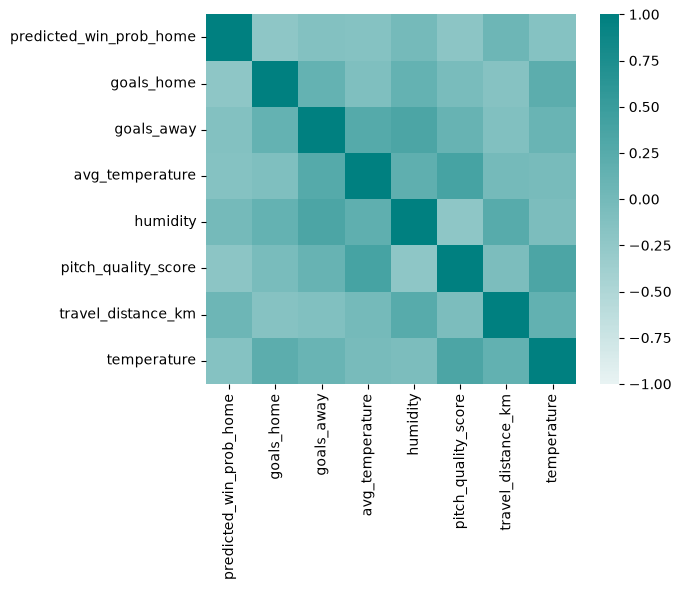

In [154]:
# review matchmerge dataFrame using heatmap visulisation
# https://seaborn.pydata.org/generated/seaborn.dark_palette.html#seaborn.dark_palette
# seaborn.dark_palette(color="teal", n_colors=8, reverse=False, as_cmap=False, input='rgb')

print("Plot the correlation matrix of 'matchmerge' using heatmap seaborn package")
sns.heatmap(
    corr2,
    vmin=-1, vmax=1, center=0,
    cmap=sns.light_palette(color="teal", n_colors=200, reverse=False, as_cmap=False, input='rgb'),
    square=True
)

In [155]:
matchmerge.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   match_id                 800 non-null    str    
 1   date                     800 non-null    str    
 2   team_home                800 non-null    str    
 3   team_away                800 non-null    str    
 4   venue_id                 800 non-null    str    
 5   group_stage              800 non-null    str    
 6   predicted_win_prob_home  800 non-null    float64
 7   goals_home               800 non-null    int64  
 8   goals_away               800 non-null    int64  
 9   venue_name               800 non-null    str    
 10  city                     800 non-null    str    
 11  country                  800 non-null    str    
 12  avg_temperature          800 non-null    float64
 13  humidity                 800 non-null    int64  
 14  pitch_quality_score      800 non-null